# DS 301 – Lab 4: Data Cleaning and Preprocessing
## Netflix Originals Data

**Objective:** Apply different data cleaning and preprocessing techniques including categorical encoding and feature scaling to make the Netflix Originals dataset ML-ready.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---
## Task 1: Initial Analysis
**Print the first 10 rows of the data to see how the data looks like.**

In [2]:
# Load the dataset
df = pd.read_csv('netflix_originals.csv')

# Display the first 10 rows
df.head(10)

,titles,years,genres,imdb,runtime,description,stars,votes,type,original
0,Zumbo's Just Desserts,2016,Reality-TV,6.9,52 min,Amateur Australian chefs compete to impress pa...,"Gigi Falanga, Rachel Khoo, Adriano Zumbo","1,779",TV Show,Netflix
1,Zona Rosa,2019,Comedy,6.0,NaN,Add a Plot,"Ray Contreras, Pablo Morán, Manu Nna, Ana Juli...",33,TV Show,Netflix
2,Young Wallander,2020,"Crime, Drama, Mystery",6.7,NaN,Follow recently graduated police officer Kurt ...,"Adam Pålsson, Leanne Best, Richard Dillane, El...","5,419",TV Show,Netflix
3,You vs. Wild,2019,"Adventure, Reality-TV",6.7,20 min,"In this interactive series, you'll make key de...",Bear Grylls,"1,977",TV Show,Netflix
4,You,2018,"Crime, Drama, Romance",7.8,45 min,"A dangerously charming, intensely obsessive yo...","Penn Badgley, Victoria Pedretti, Ambyr Childer...","134,932",TV Show,Netflix
5,YooHoo to the Rescue,2019,Family,6.9,NaN,"In a series of magical missions, quick-witted ...","Ryan Bartley, Kira Buckland, Lucien Dodge, Kyl...",37,TV Show,Netflix
6,Yankee,2019,Drama,6.0,40 min,"On the run from the police, an Arizona man cro...","Pablo Lyle, Ana Layevska, Pamela Almanza, Seba...",458,TV Show,Netflix
7,Wu Assassins,2019,"Action, Crime, Drama",6.4,44 min,A warrior chosen as the latest and last Wu Ass...,"Iko Uwais, Byron Mann, Li Jun Li, Lawrence Kao","9,336",TV Show,Netflix
8,World's Most Wanted,2020,"Documentary, Crime",7.1,NaN,Heinous criminals have avoided capture despite...,"Jennifer Julian, Thomas Fuentes, Calogero Germ...","1,495",TV Show,Netflix
9,World of Winx,2016,"Animation, Action, Comedy",6.8,30 min,The Winx travel all over the world searching f...,"Rebecca Soler, Alysha Deslorieux, Haven Pascha...",556,TV Show,Netflix


In [3]:
# General info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1517 entries, 0 to 1516
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   titles       1517 non-null   object 
 1   years        1517 non-null   int64  
 2   genres       1516 non-null   object 
 3   imdb         1512 non-null   float64
 4   runtime      1276 non-null   object 
 5   description  1517 non-null   object 
 6   stars        1489 non-null   object 
 7   votes        1516 non-null   object 
 8   type         1517 non-null   object 
 9   original     1517 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 118.6+ KB


In [4]:
# Descriptive statistics
df.describe()

,years,imdb
count,1517.000000,1512.000000
mean,2018.145023,6.685516
std,1.858819,1.100915
min,2001.000000,2.400000
25%,2017.000000,6.000000
50%,2018.000000,6.800000
75%,2020.000000,7.500000
max,2020.000000,9.300000


---
## Task 2: Data Shape
**Print the shape of the data to find the number of rows and columns.**

In [5]:
# Print the shape of the dataset
print(f"Shape of the dataset: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")

Shape of the dataset: (1517, 10)
Number of rows: 1517
Number of columns: 10

Column names: ['titles', 'years', 'genres', 'imdb', 'runtime', 'description', 'stars', 'votes', 'type', 'original']


---
## Task 3: Genre Extraction
**The genre column has multiple values in each row. Extract only the first genre from each row.**

In [6]:
# Show examples of multi-genre entries before cleaning
print("Sample genre values before cleaning:")
print(df['genres'].head(10))

Sample genre values before cleaning:
0                   Reality-TV
1                       Comedy
2        Crime, Drama, Mystery
3        Adventure, Reality-TV
4        Crime, Drama, Romance
5                       Family
6                        Drama
7         Action, Crime, Drama
8           Documentary, Crime
9    Animation, Action, Comedy
Name: genres, dtype: object


In [7]:
# Extract only the first genre from each row by splitting on the comma
df['genres'] = df['genres'].astype(str).str.split(',').str[0].str.strip()

# Verify the cleaning
print("Sample genre values after cleaning:")
print(df['genres'].head(10))
print(f"\nUnique genres: {df['genres'].nunique()}")
print(f"Genre values: {sorted(df['genres'].unique())}")

Sample genre values after cleaning:
0     Reality-TV
1         Comedy
2          Crime
3      Adventure
4          Crime
5         Family
6          Drama
7         Action
8    Documentary
9      Animation
Name: genres, dtype: object

Unique genres: 24
Genre values: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'nan']


---
## Task 4: Missing Values
**Find the number of missing values. If there are missing values, choose an appropriate method (mean/median/mode imputation or dropping). Provide clear justification.**

In [8]:
# Check for missing values in each column
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage.round(2)
})

print("Missing Values Summary:")
print(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values Summary:
             Missing Values  Percentage (%)
titles                    0            0.00
years                     0            0.00
genres                    0            0.00
imdb                      5            0.33
runtime                 241           15.89
description               0            0.00
stars                    28            1.85
votes                     1            0.07
type                      0            0.00
original                  0            0.00

Total missing values: 275


In [9]:
# Check the 'runtime' column — it contains strings like '52 min', need to clean first
print("Sample runtime values:")
print(df['runtime'].head(20))
print(f"\nRuntime dtype: {df['runtime'].dtype}")

Sample runtime values:
0     52 min
1        NaN
2        NaN
3     20 min
4     45 min
5        NaN
6     40 min
7     44 min
8        NaN
9     30 min
10       NaN
11    11 min
12    45 min
13    48 min
14    60 min
15    55 min
16       NaN
17    30 min
18    30 min
19    50 min
Name: runtime, dtype: object

Runtime dtype: object


In [10]:
# Clean the 'runtime' column: remove ' min' and convert to numeric
df['runtime'] = df['runtime'].astype(str).str.replace(' min', '', regex=False)
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')

# Clean the 'votes' column: remove commas and convert to numeric
df['votes'] = df['votes'].astype(str).str.replace(',', '', regex=False)
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# Check missing values again after type conversion
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage.round(2)
})

print("Missing Values After Type Conversion:")
print(missing_df)

Missing Values After Type Conversion:
             Missing Values  Percentage (%)
titles                    0            0.00
years                     0            0.00
genres                    0            0.00
imdb                      5            0.33
runtime                 241           15.89
description               0            0.00
stars                    28            1.85
votes                     1            0.07
type                      0            0.00
original                  0            0.00


In [11]:
# Handle missing values with justification

# --- runtime (numerical) ---
# Justification: Use MEDIAN imputation for 'runtime' because:
# - Runtime is a numerical column that may have outliers (e.g., very long documentaries or short episodes)
# - Median is robust to outliers unlike mean
# - We don't want to drop these rows as they contain other valuable information
runtime_median = df['runtime'].median()
print(f"Runtime median: {runtime_median}")
df['runtime'].fillna(runtime_median, inplace=True)

# --- imdb (numerical) ---
# Justification: Use MEDIAN imputation for 'imdb' because:
# - IMDB ratings can be skewed (more shows tend to have moderate ratings)
# - Median preserves the central tendency without being affected by extreme ratings
imdb_median = df['imdb'].median()
print(f"IMDB median: {imdb_median}")
df['imdb'].fillna(imdb_median, inplace=True)

# --- description (text/categorical) ---
# Justification: Use MODE imputation or fill with 'No Description'
# - Description is a text column not used for ML modeling directly
# - Filling with a placeholder is appropriate since we can't meaningfully impute text
df['description'].fillna('No Description', inplace=True)

# --- stars (text/categorical) ---
# Justification: Fill with 'Unknown' because:
# - Stars is a text column listing cast members
# - Cannot meaningfully impute actor names
# - Dropping would lose other valuable data in the row
df['stars'].fillna('Unknown', inplace=True)

# --- votes (numerical) ---
# Justification: Use MEDIAN imputation for 'votes' because:
# - Vote counts are typically right-skewed (few shows get very high votes)
# - Median is more representative of a "typical" vote count than mean
votes_median = df['votes'].median()
print(f"Votes median: {votes_median}")
df['votes'].fillna(votes_median, inplace=True)

# Verify no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print(df.isnull().sum())

Runtime median: 62.0
IMDB median: 6.8
Votes median: 2021.5

Remaining missing values: 0
titles         0
years          0
genres         0
imdb           0
runtime        0
description    0
stars          0
votes          0
type           0
original       0
dtype: int64


**Summary of Missing Value Handling:**

| Column | Method | Justification |
|--------|--------|---------------|
| `runtime` | Median Imputation | Numerical column, median is robust to outliers from varying show lengths |
| `imdb` | Median Imputation | IMDB ratings can be skewed; median preserves central tendency |
| `description` | Filled with 'No Description' | Text column — imputation isn't meaningful; placeholder preserves rows |
| `stars` | Filled with 'Unknown' | Text column — can't impute actor names; preserves other row data |
| `votes` | Median Imputation | Vote counts are right-skewed; median is more representative than mean |

---
## Task 5: Numerical Histograms
**Plot the histograms for numerical data.**

Numerical columns: ['years', 'imdb', 'runtime', 'votes']


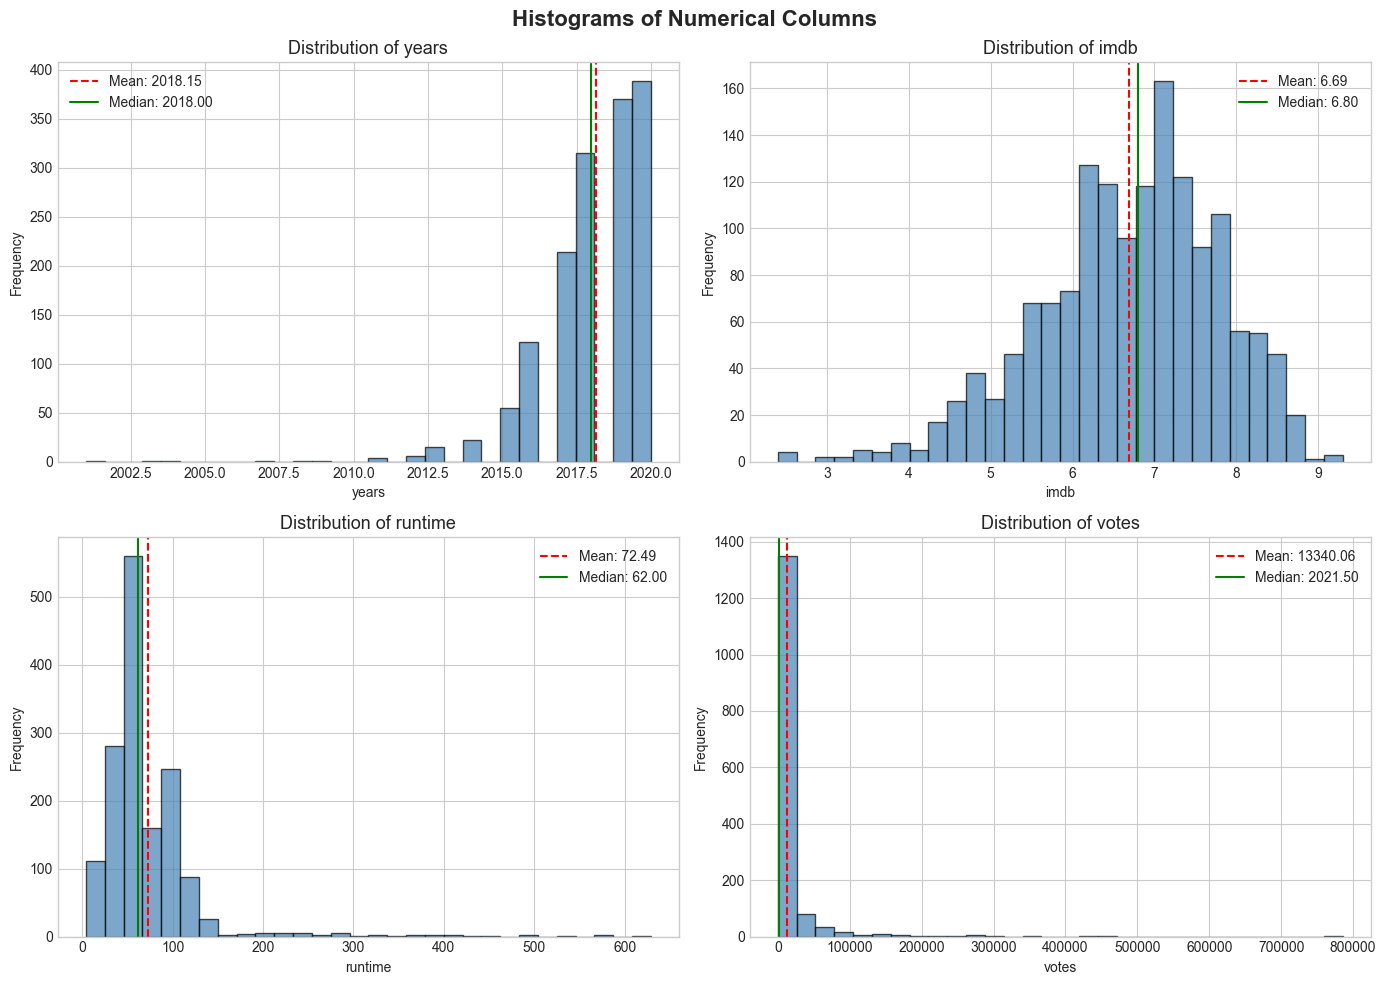

In [12]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Plot histograms for each numerical column
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histograms of Numerical Columns', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2][idx % 2]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='-', label=f'Median: {df[col].median():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

---
## Task 6: Genre Visualization
**Plot the bar chart for top 10 genres.**

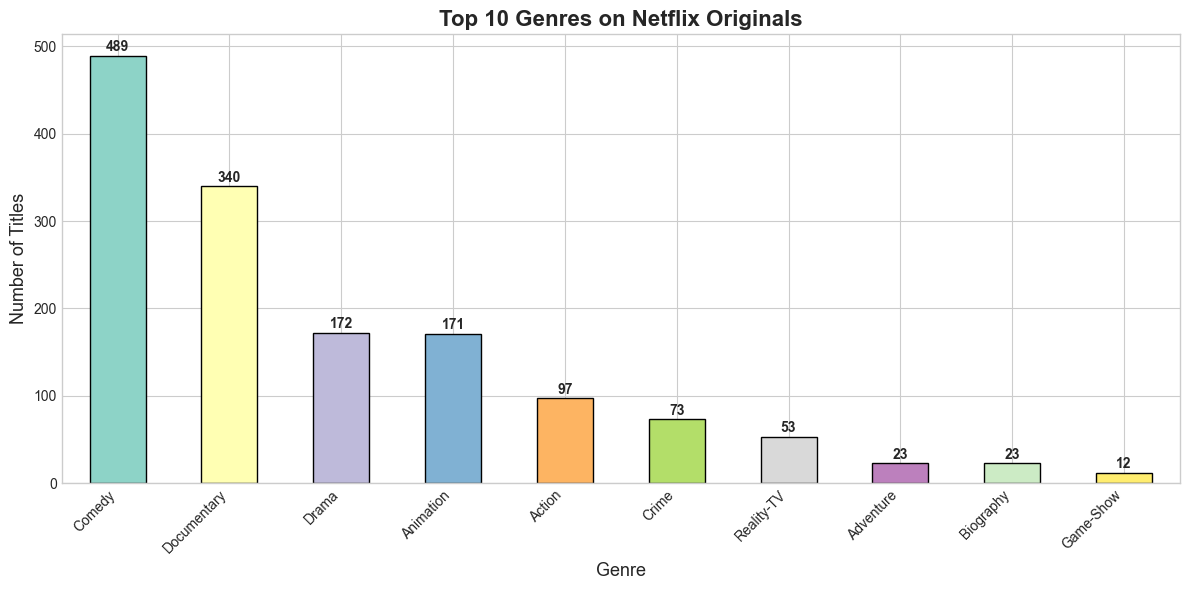

In [13]:
# Get the top 10 genres by count
top_10_genres = df['genres'].value_counts().head(10)

# Plot bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Set3(np.linspace(0, 1, 10))
top_10_genres.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Top 10 Genres on Netflix Originals', fontsize=16, fontweight='bold')
ax.set_xlabel('Genre', fontsize=13)
ax.set_ylabel('Number of Titles', fontsize=13)
ax.set_xticklabels(top_10_genres.index, rotation=45, ha='right')

# Add value labels on bars
for i, v in enumerate(top_10_genres.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Task 7: Release Trends
**Plot the line chart for the number of releases per year.**

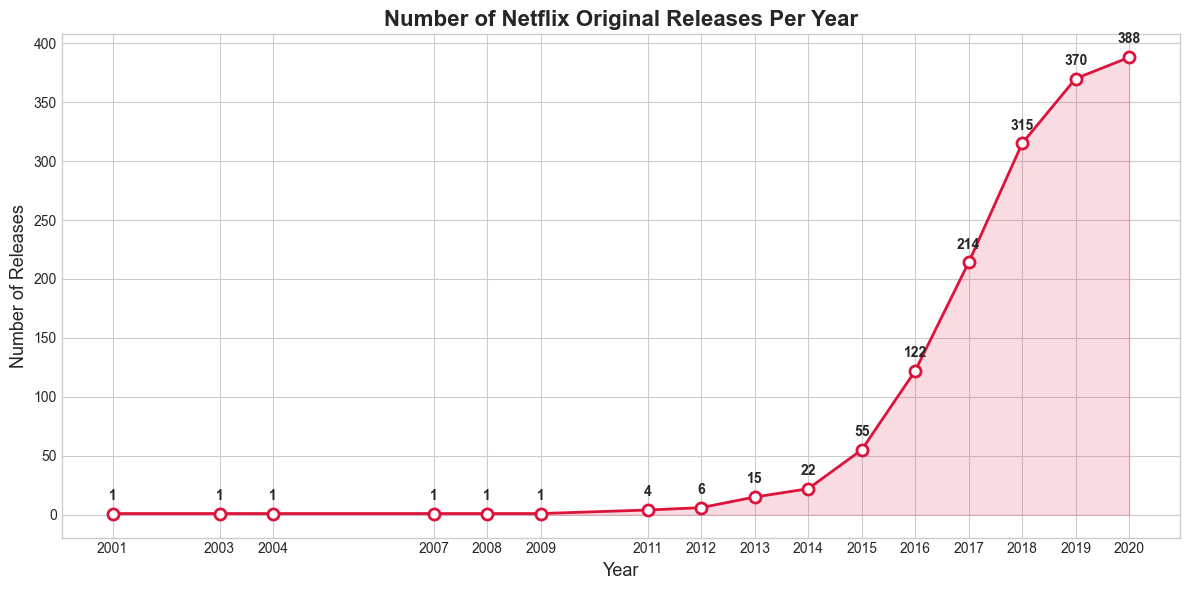

In [14]:
# Count releases per year
releases_per_year = df['years'].value_counts().sort_index()

# Plot line chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(releases_per_year.index, releases_per_year.values, 
        marker='o', linewidth=2, color='crimson', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(releases_per_year.index, releases_per_year.values, alpha=0.15, color='crimson')
ax.set_title('Number of Netflix Original Releases Per Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of Releases', fontsize=13)
ax.set_xticks(releases_per_year.index)

# Add data labels
for x, y in zip(releases_per_year.index, releases_per_year.values):
    ax.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Task 8: Categorical Encoding
**Perform encoding on the categorical data. Choose between label encoding, one hot encoding, or ordinal encoding and provide a clear justification.**

In [15]:
# Identify categorical columns relevant for ML
# We exclude 'titles', 'description', and 'stars' as they are high-cardinality text fields
# and are not useful as-is for ML modeling
categorical_cols = ['genres', 'type', 'original']
print("Categorical columns to encode:", categorical_cols)
for col in categorical_cols:
    print(f"\n{col} — Unique values ({df[col].nunique()}): {df[col].unique()[:15]}")

Categorical columns to encode: ['genres', 'type', 'original']

genres — Unique values (24): ['Reality-TV' 'Comedy' 'Crime' 'Adventure' 'Family' 'Drama' 'Action'
 'Documentary' 'Animation' 'Talk-Show' 'Musical' 'Game-Show' 'Horror'
 'Thriller' 'Short']

type — Unique values (2): ['TV Show' 'Movie']

original — Unique values (1): ['Netflix']


In [16]:
# Create a copy for encoding
df_encoded = df.copy()

# --- Encoding Strategy ---

# 1. 'genres' - Label Encoding
# Justification: Genres have a moderate number of unique categories (~15-20).
# One-hot encoding would create too many columns.
# Label encoding is appropriate here because we plan to use tree-based models
# in the future, which handle label-encoded features well.
# Ordinal encoding is not suitable since genres don't have a natural order.
le_genres = LabelEncoder()
df_encoded['genres_encoded'] = le_genres.fit_transform(df_encoded['genres'])
print("Genre Encoding Mapping:")
for label, encoded in zip(le_genres.classes_, le_genres.transform(le_genres.classes_)):
    print(f"  {label} -> {encoded}")

# 2. 'type' - Label Encoding
# Justification: 'type' has only 2 values (TV Show, Movie), making label encoding
# the simplest and most efficient choice. Binary categorical variables can be
# safely label-encoded without introducing ordinal assumptions.
le_type = LabelEncoder()
df_encoded['type_encoded'] = le_type.fit_transform(df_encoded['type'])
print(f"\nType Encoding Mapping:")
for label, encoded in zip(le_type.classes_, le_type.transform(le_type.classes_)):
    print(f"  {label} -> {encoded}")

# 3. 'original' - Label Encoding
# Justification: 'original' has very few unique values.
# Label encoding is efficient and appropriate for low-cardinality nominal features.
le_original = LabelEncoder()
df_encoded['original_encoded'] = le_original.fit_transform(df_encoded['original'])
print(f"\nOriginal Encoding Mapping:")
for label, encoded in zip(le_original.classes_, le_original.transform(le_original.classes_)):
    print(f"  {label} -> {encoded}")

print("\n--- Encoded DataFrame (first 5 rows, selected columns) ---")
df_encoded[['genres', 'genres_encoded', 'type', 'type_encoded', 'original', 'original_encoded']].head()

Genre Encoding Mapping:
  Action -> 0
  Adventure -> 1
  Animation -> 2
  Biography -> 3
  Comedy -> 4
  Crime -> 5
  Documentary -> 6
  Drama -> 7
  Family -> 8
  Fantasy -> 9
  Game-Show -> 10
  History -> 11
  Horror -> 12
  Music -> 13
  Musical -> 14
  Mystery -> 15
  Reality-TV -> 16
  Romance -> 17
  Sci-Fi -> 18
  Short -> 19
  Sport -> 20
  Talk-Show -> 21
  Thriller -> 22
  nan -> 23

Type Encoding Mapping:
  Movie -> 0
  TV Show -> 1

Original Encoding Mapping:
  Netflix -> 0

--- Encoded DataFrame (first 5 rows, selected columns) ---


,genres,genres_encoded,type,type_encoded,original,original_encoded
0,Reality-TV,16,TV Show,1,Netflix,0
1,Comedy,4,TV Show,1,Netflix,0
2,Crime,5,TV Show,1,Netflix,0
3,Adventure,1,TV Show,1,Netflix,0
4,Crime,5,TV Show,1,Netflix,0


**Encoding Justification Summary:**

| Column | Method | Justification |
|--------|--------|---------------|
| `genres` | Label Encoding | Moderate cardinality (~15-20 genres); one-hot would add too many columns. Works well with tree-based models. |
| `type` | Label Encoding | Binary (TV Show/Movie) — can be safely label-encoded with no ordinal bias. |
| `original` | Label Encoding | Low cardinality — efficient and simple. |

**Why not One-Hot Encoding?** One-hot encoding for `genres` would create ~15-20 new columns, leading to the "curse of dimensionality" especially for this relatively small dataset. For `type` and `original`, which have very few categories, label encoding is simpler and equally effective.

**Why not Ordinal Encoding?** These categorical variables don't have a natural inherent order (e.g., "Comedy" is not greater than "Drama"), so ordinal encoding would inappropriately impose an order.

---
## Task 9: Outlier Handling
**Identify if there are any outliers in the data. If so, handle the outliers.**

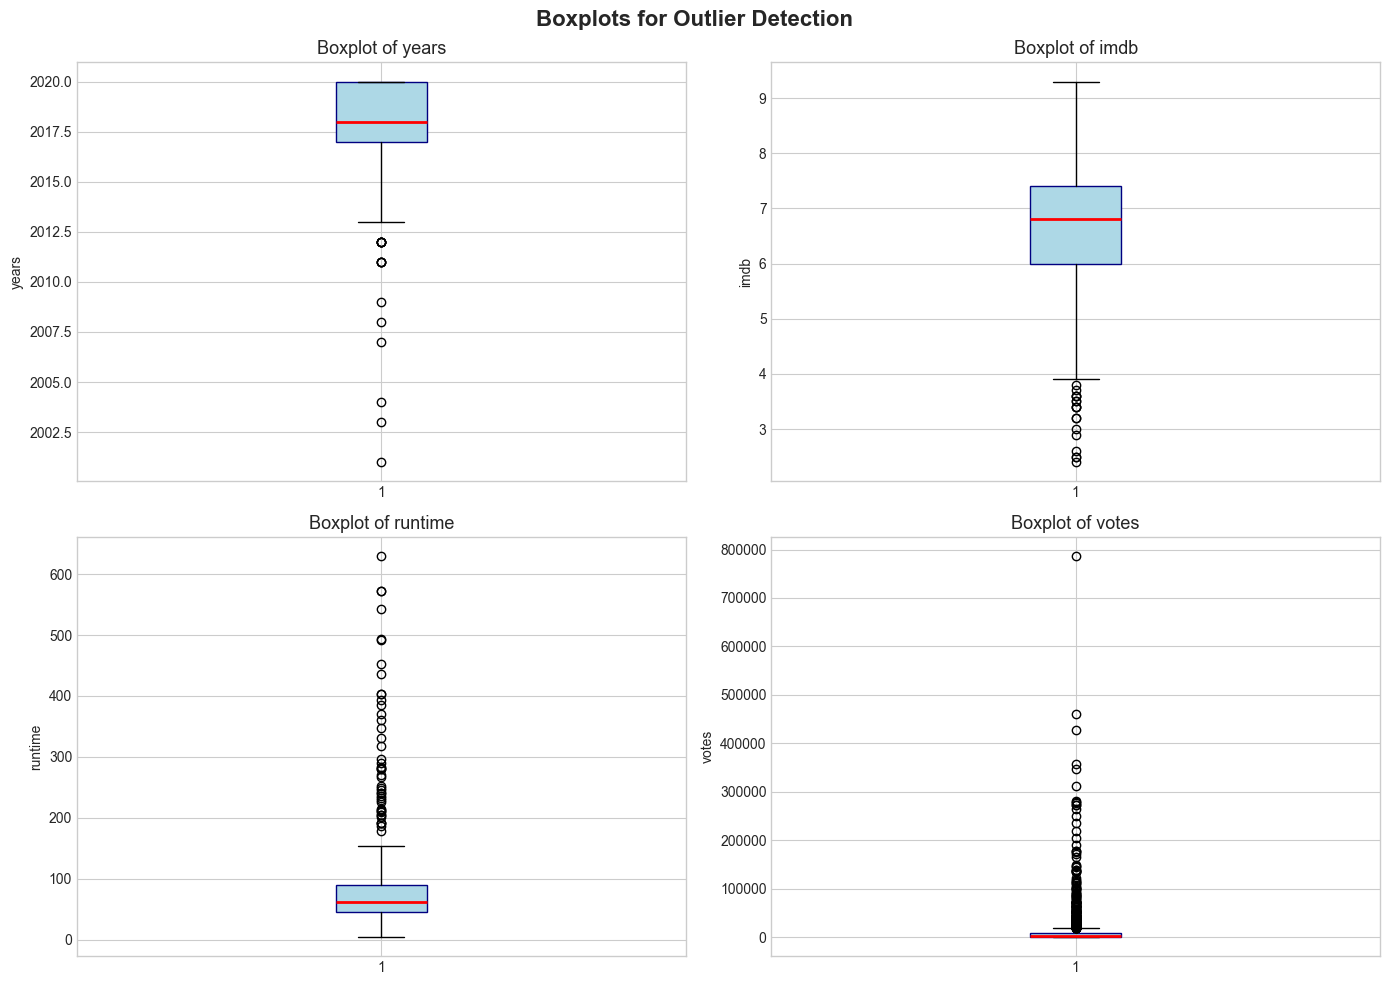

In [17]:
# Identify outliers using boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2][idx % 2]
    ax.boxplot(df_encoded[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Boxplot of {col}', fontsize=13)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [18]:
# Quantify outliers using IQR method
def detect_outliers_iqr(data, column):
    """Detect outliers using the IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outlier Detection Summary (IQR Method):")
print("=" * 60)
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df_encoded, col)
    print(f"\n{col}:")
    print(f"  Lower Bound: {lb:.2f}, Upper Bound: {ub:.2f}")
    print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df_encoded)*100:.1f}%)")

Outlier Detection Summary (IQR Method):

years:
  Lower Bound: 2012.50, Upper Bound: 2024.50
  Number of outliers: 16 (1.1%)

imdb:
  Lower Bound: 3.90, Upper Bound: 9.50
  Number of outliers: 18 (1.2%)

runtime:
  Lower Bound: -22.50, Upper Bound: 157.50
  Number of outliers: 46 (3.0%)

votes:
  Lower Bound: -9970.50, Upper Bound: 18113.50
  Number of outliers: 224 (14.8%)


In [19]:
# Handle outliers by capping (Winsorization)
# Justification: Rather than removing outliers (which would reduce our dataset),
# we cap them at the IQR boundaries. This preserves all data points while
# limiting the influence of extreme values.

def cap_outliers_iqr(data, column):
    """Cap outliers at IQR boundaries."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

for col in numerical_cols:
    df_encoded = cap_outliers_iqr(df_encoded, col)

# Verify outliers have been handled
print("After Outlier Handling:")
print("=" * 60)
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df_encoded, col)
    print(f"{col}: {len(outliers)} outliers remaining")

After Outlier Handling:
years: 0 outliers remaining
imdb: 0 outliers remaining
runtime: 0 outliers remaining
votes: 0 outliers remaining


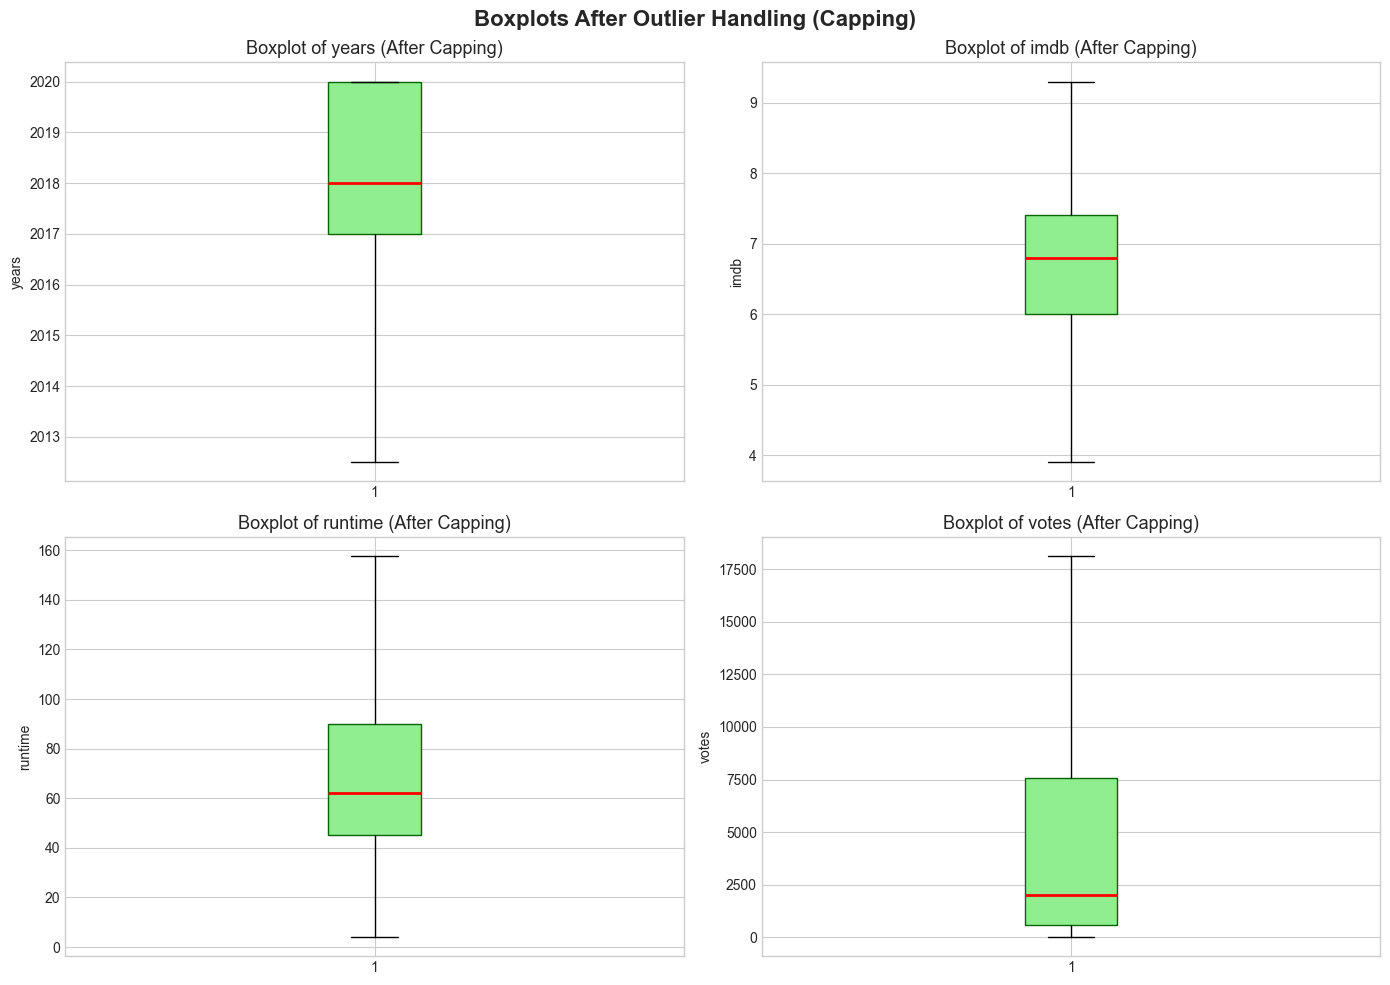

In [20]:
# Visualize after outlier handling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots After Outlier Handling (Capping)', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2][idx % 2]
    ax.boxplot(df_encoded[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen', color='darkgreen'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Boxplot of {col} (After Capping)', fontsize=13)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

---
## Task 10: Outlier Theory
**If given an option to replace the outliers with 0, would you do that? Why or why not?**

**No, replacing outliers with 0 is generally NOT recommended.** Here's why:

1. **Distortion of Data Distribution:** Replacing outliers with 0 would artificially skew the distribution of the data. For example, if a show has an IMDB rating of 9.5 (an outlier), replacing it with 0 would make it seem like the show had an extremely low rating, which is inaccurate and misleading.

2. **Introduction of False Information:** A value of 0 for columns like `runtime`, `imdb`, or `votes` implies a meaningful value (e.g., 0 minutes runtime, 0 rating, 0 votes), which is essentially incorrect data. This creates noise rather than reducing it.

3. **Impact on Statistical Measures:** Replacing with 0 would drastically lower the mean and alter the variance, standard deviation, and other statistical properties of the data, leading to poor model performance.

4. **Better Alternatives Exist:**
   - **Capping/Winsorization** (as used above): Clips extreme values to IQR boundaries, preserving relative order.
   - **Transformation** (e.g., log transformation): Reduces the impact of outliers while preserving the data.
   - **Imputation with median:** Replaces outliers with a central, representative value.
   - **Removal:** If the dataset is large enough, removing outlier rows is also an option.

**Conclusion:** Zero-replacement treats all outliers the same regardless of context and introduces values that are factually wrong. Capping or transformation methods are far more appropriate as they retain the relative ordering of the data while reducing the influence of extreme values.

---
## Task 11: Feature Scaling
**Perform feature scaling using `StandardScaler`, `MinMaxScaler`, and `RobustScaler`. Which method is the most appropriate for this data and why?**

In [21]:
# Select numerical features for scaling
features_to_scale = ['years', 'imdb', 'runtime', 'votes']
print("Features to scale:", features_to_scale)
print("\nOriginal data statistics:")
df_encoded[features_to_scale].describe()

Features to scale: ['years', 'imdb', 'runtime', 'votes']

Original data statistics:


,years,imdb,runtime,votes
count,1517.000000,1517.000000,1517.000000,1517.000000
mean,2018.179301,6.694067,67.841793,5265.697100
std,1.680485,1.074466,32.438764,6446.405507
min,2012.500000,3.900000,4.000000,5.000000
25%,2017.000000,6.000000,45.000000,561.000000
50%,2018.000000,6.800000,62.000000,2021.500000
75%,2020.000000,7.400000,90.000000,7582.000000
max,2020.000000,9.300000,157.500000,18113.500000


In [22]:
# 1. StandardScaler — Standardization (zero mean, unit variance)
scaler_standard = StandardScaler()
df_standard = pd.DataFrame(
    scaler_standard.fit_transform(df_encoded[features_to_scale]),
    columns=[f"{col}_standard" for col in features_to_scale]
)

print("StandardScaler Results:")
print(df_standard.describe().round(3))

StandardScaler Results:
       years_standard  imdb_standard  runtime_standard  votes_standard
count        1517.000       1517.000          1517.000        1517.000
mean           -0.000          0.000             0.000           0.000
std             1.000          1.000             1.000           1.000
min            -3.381         -2.601            -1.969          -0.816
25%            -0.702         -0.646            -0.704          -0.730
50%            -0.107          0.099            -0.180          -0.503
75%             1.084          0.657             0.683           0.359
max             1.084          2.426             2.765           1.994


In [23]:
# 2. MinMaxScaler — Normalization (scales to [0, 1])
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df_encoded[features_to_scale]),
    columns=[f"{col}_minmax" for col in features_to_scale]
)

print("MinMaxScaler Results:")
print(df_minmax.describe().round(3))

MinMaxScaler Results:
       years_minmax  imdb_minmax  runtime_minmax  votes_minmax
count      1517.000     1517.000        1517.000      1517.000
mean          0.757        0.517           0.416         0.291
std           0.224        0.199           0.211         0.356
min           0.000        0.000           0.000         0.000
25%           0.600        0.389           0.267         0.031
50%           0.733        0.537           0.378         0.111
75%           1.000        0.648           0.560         0.418
max           1.000        1.000           1.000         1.000


In [24]:
# 3. RobustScaler — Uses median and IQR (robust to outliers)
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(
    scaler_robust.fit_transform(df_encoded[features_to_scale]),
    columns=[f"{col}_robust" for col in features_to_scale]
)

print("RobustScaler Results:")
print(df_robust.describe().round(3))

RobustScaler Results:
       years_robust  imdb_robust  runtime_robust  votes_robust
count      1517.000     1517.000        1517.000      1517.000
mean          0.060       -0.076           0.130         0.462
std           0.560        0.767           0.721         0.918
min          -1.833       -2.071          -1.289        -0.287
25%          -0.333       -0.571          -0.378        -0.208
50%           0.000        0.000           0.000         0.000
75%           0.667        0.429           0.622         0.792
max           0.667        1.786           2.122         2.292


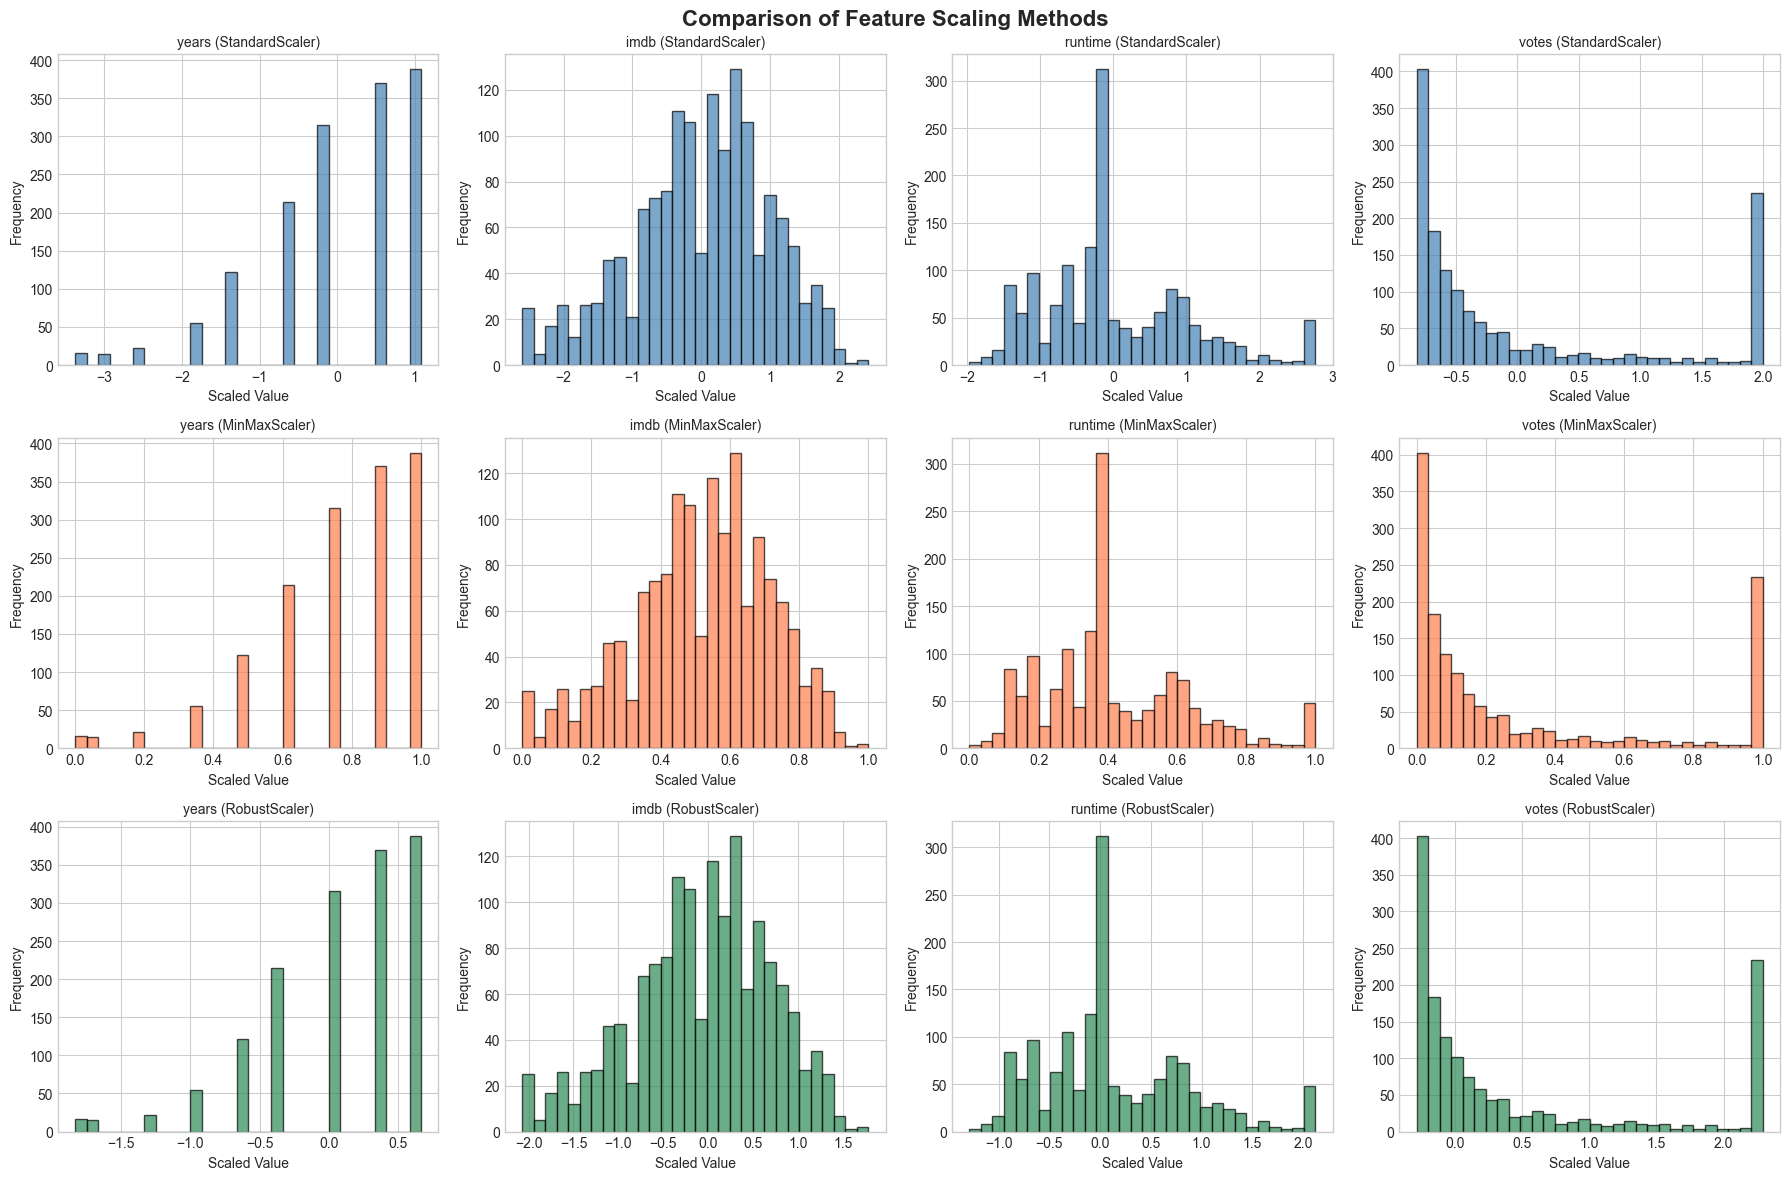

In [25]:
# Visual comparison of all three scaling methods
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Comparison of Feature Scaling Methods', fontsize=16, fontweight='bold')

scalers = {
    'StandardScaler': df_standard,
    'MinMaxScaler': df_minmax,
    'RobustScaler': df_robust
}
colors = ['steelblue', 'coral', 'seagreen']

for row_idx, (scaler_name, scaled_df) in enumerate(scalers.items()):
    for col_idx, col in enumerate(features_to_scale):
        ax = axes[row_idx][col_idx]
        ax.hist(scaled_df.iloc[:, col_idx], bins=30, color=colors[row_idx], 
                edgecolor='black', alpha=0.7)
        ax.set_title(f'{col} ({scaler_name})', fontsize=10)
        ax.set_xlabel('Scaled Value')
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Which scaling method is most appropriate?

**`RobustScaler` is the most appropriate method for this dataset.** Here's the reasoning:

| Scaler | How it works | Pros | Cons |
|--------|-------------|------|------|
| **StandardScaler** | Centers to mean=0, std=1 | Works well for normally distributed data | Sensitive to outliers; our data (votes, runtime) is skewed |
| **MinMaxScaler** | Scales to [0, 1] range | Good for bounded features | Very sensitive to outliers; a single extreme value compresses all others |
| **RobustScaler** | Uses median and IQR | Robust to outliers; handles skewed distributions | Does not bound values to a specific range |

**Why RobustScaler is best for this data:**

1. **Skewed distributions:** Columns like `votes` and `runtime` are heavily right-skewed (many shows with few votes, a few shows with massive vote counts). RobustScaler uses the median and IQR, which are not affected by extreme values.

2. **Outlier presence:** Even after capping, the data still has varying ranges across features. RobustScaler handles this better than StandardScaler or MinMaxScaler because it doesn't rely on mean/std (StandardScaler) or min/max (MinMaxScaler), which can be distorted by outliers.

3. **Preservation of data structure:** RobustScaler preserves the relative spacing between most data points while reducing the influence of extreme values, making it ideal for datasets with non-normal distributions like this Netflix dataset.

In [26]:
# Final ML-ready dataset preview
# Combine the encoded and scaled features
df_final = df_encoded[['titles', 'years', 'imdb', 'runtime', 'votes', 
                        'genres_encoded', 'type_encoded', 'original_encoded']].copy()

# Apply RobustScaler (our chosen scaler) to numerical features
scaler = RobustScaler()
df_final[['years', 'imdb', 'runtime', 'votes']] = scaler.fit_transform(
    df_final[['years', 'imdb', 'runtime', 'votes']]
)

print("Final ML-Ready Dataset (first 10 rows):")
df_final.head(10)

Final ML-Ready Dataset (first 10 rows):


,titles,years,imdb,runtime,votes,genres_encoded,type_encoded,original_encoded
0,Zumbo's Just Desserts,-0.666667,0.071429,-0.222222,-0.034539,16,1,0
1,Zona Rosa,0.333333,-0.571429,0.000000,-0.283222,4,1,0
2,Young Wallander,0.666667,-0.071429,0.000000,0.483905,5,1,0
3,You vs. Wild,0.333333,-0.071429,-0.933333,-0.006338,1,1,0
4,You,0.000000,0.714286,-0.377778,2.291981,5,1,0
5,YooHoo to the Rescue,0.333333,0.071429,0.000000,-0.282652,8,1,0
6,Yankee,0.333333,-0.571429,-0.488889,-0.222689,7,1,0
7,Wu Assassins,0.333333,-0.285714,-0.400000,1.041803,0,1,0
8,World's Most Wanted,0.666667,0.214286,0.000000,-0.074989,6,1,0
9,World of Winx,-0.666667,0.000000,-0.711111,-0.208731,2,1,0


In [27]:
print(f"\nFinal dataset shape: {df_final.shape}")
print(f"\nFinal dataset info:")
df_final.info()
print(f"\nFinal dataset statistics:")
df_final.describe()


Final dataset shape: (1517, 8)

Final dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1517 entries, 0 to 1516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   titles            1517 non-null   object 
 1   years             1517 non-null   float64
 2   imdb              1517 non-null   float64
 3   runtime           1517 non-null   float64
 4   votes             1517 non-null   float64
 5   genres_encoded    1517 non-null   int64  
 6   type_encoded      1517 non-null   int64  
 7   original_encoded  1517 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 94.9+ KB

Final dataset statistics:


,years,imdb,runtime,votes,genres_encoded,type_encoded,original_encoded
count,1517.000000,1517.000000,1517.000000,1517.000000,1517.000000,1517.000000,1517.0
mean,0.059767,-0.075666,0.129818,0.462071,5.218194,0.667106,0.0
std,0.560162,0.767476,0.720861,0.918161,3.662797,0.471404,0.0
min,-1.833333,-2.071429,-1.288889,-0.287210,0.000000,0.000000,0.0
25%,-0.333333,-0.571429,-0.377778,-0.208019,4.000000,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.0
75%,0.666667,0.428571,0.622222,0.791981,6.000000,1.000000,0.0
max,0.666667,1.785714,2.122222,2.291981,23.000000,1.000000,0.0
